# EDA
## Projektbeskrivning
RightHome är en bostadsplattform som hjälper användare att hitta rätt bostad 
på rätt plats. I denna EDA undersöker vi bostadsdata från hela Sverige för 
att förstå hur pris, område, upplåtelseform och servicetillgång hänger ihop.

## Syfte
- Förstå prisstrukturen på den svenska bostadsmarknaden
- Identifiera vilka faktorer som påverkar bostadspriset mest
- Hitta mönster och insikter som kan stödja RightHomes rekommendationssystem


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset
Vi arbetar med fyra datakällor:
- `bostader.csv` – Bostadsinformation (typ, rum, boyta, upplåtelseform)
- `priser.csv`   – Prisinformation per bostad (pris, avgift, kvm-pris)
- `platser.csv`  – Områdesinformation (område, stad, befolkning)
- `visningar.csv`– Visningsdata per bostad


In [55]:
df_bostader  = pd.read_csv("../ETL_Pipline/bostader.csv")
df_platser   = pd.read_csv("../ETL_Pipline/platser.csv")
df_priser    = pd.read_csv("../ETL_Pipline/priser.csv")
df_visningar = pd.read_csv("../ETL_Pipline/visningar.csv")

df_bostader.head()

,id,typ,upplåtelseform,rum,boyta,boyta_enhet,tillgänglig,created_at,adress,lat,lon,plats_id,sparad,poi_kollektivtrafik,poi_utbildning_kultur,poi_mat_shopping,poi_fritid,poi_religion_tro,poi_halsa,poi_ovrigt
0,1,lägenhet,köpa,5,100,m²,False,2025-09-30,Drottninggatan 19,55.55919,12.97429,1,0,54,1,22,28,0,2,1
1,2,hus,köpa,1,20,m²,True,2025-06-05,Bergsgatan 93,59.33706,18.07866,2,0,205,17,715,34,11,20,20
2,3,hus,köpa,6,126,m²,True,2025-12-11,Lindvägen 89,55.58954,13.03073,3,0,87,6,132,72,2,3,6
3,4,lägenhet,köpa,2,36,m²,True,2025-09-14,Storgatan 117,55.61235,12.97689,4,0,36,7,119,13,1,2,2
4,5,lägenhet,hyra,6,138,m²,True,2026-02-25,Sveavägen 119,55.58740,13.03219,3,0,74,1,89,83,2,3,6


In [56]:
print(df_bostader.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1000 non-null   int64  
 1   typ                    1000 non-null   object 
 2   upplåtelseform         1000 non-null   object 
 3   rum                    1000 non-null   int64  
 4   boyta                  1000 non-null   int64  
 5   boyta_enhet            1000 non-null   object 
 6   tillgänglig            1000 non-null   bool   
 7   created_at             1000 non-null   object 
 8   adress                 1000 non-null   object 
 9   lat                    1000 non-null   float64
 10  lon                    1000 non-null   float64
 11  plats_id               1000 non-null   int64  
 12  sparad                 1000 non-null   int64  
 13  poi_kollektivtrafik    1000 non-null   int64  
 14  poi_utbildning_kultur  1000 non-null   int64  
 15  poi_m

In [57]:
print(df_platser.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   område             20 non-null     object
 1   stad               20 non-null     object
 2   plats_id           20 non-null     int64 
 3   kommun_befolkning  20 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 772.0+ bytes
None


In [58]:
print(df_priser.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bostad_id         1000 non-null   int64  
 1   pris              1000 non-null   int64  
 2   avgift            1000 non-null   int64  
 3   kvadratmeterpris  1000 non-null   int64  
 4   pris_per_kvm      1000 non-null   float64
 5   valuta            1000 non-null   object 
 6   manadskostnad     1000 non-null   int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 54.8+ KB
None


In [59]:
print(df_visningar.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   bostad_id      2 non-null      int64 
 1   adress         2 non-null      object
 2   visningsdatum  2 non-null      object
 3   starttid       2 non-null      object
 4   sluttid        2 non-null      object
dtypes: int64(1), object(4)
memory usage: 212.0+ bytes
None


In [60]:
print(df_bostader.describe())

                id          rum        boyta          lat          lon  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean    500.500000     3.463000    80.205000    57.568380    14.428718   
std     288.819436     1.703976    41.595759     1.552922     2.691770   
min       1.000000     1.000000    18.000000    55.558090    11.896020   
25%     250.750000     2.000000    44.000000    55.609952    11.971298   
50%     500.500000     3.000000    78.000000    57.704050    12.976190   
75%     750.250000     5.000000   112.000000    59.313173    17.998843   
max    1000.000000     6.000000   168.000000    59.386810    18.166540   

          plats_id  sparad  poi_kollektivtrafik  poi_utbildning_kultur  \
count  1000.000000  1000.0          1000.000000            1000.000000   
mean      9.063000     0.0            84.312000              11.499000   
std       5.662605     0.0            47.284675              13.001886   
min       1.000000     0.0           

In [61]:
print(df_bostader.shape)
print(df_bostader.dtypes)
print(df_bostader.isnull().sum())

(1000, 20)
id                         int64
typ                       object
upplåtelseform            object
rum                        int64
boyta                      int64
boyta_enhet               object
tillgänglig                 bool
created_at                object
adress                    object
lat                      float64
lon                      float64
plats_id                   int64
sparad                     int64
poi_kollektivtrafik        int64
poi_utbildning_kultur      int64
poi_mat_shopping           int64
poi_fritid                 int64
poi_religion_tro           int64
poi_halsa                  int64
poi_ovrigt                 int64
dtype: object
id                       0
typ                      0
upplåtelseform           0
rum                      0
boyta                    0
boyta_enhet              0
tillgänglig              0
created_at               0
adress                   0
lat                      0
lon                      0
plats_id          

In [78]:
print(df_priser.columns)
print(df_bostader.columns)
print(df_platser.columns)
print(df_visningar.columns)


Index(['bostad_id', 'pris', 'avgift', 'kvadratmeterpris', 'pris_per_kvm',
       'valuta', 'manadskostnad'],
      dtype='object')
Index(['id', 'typ', 'upplåtelseform', 'rum', 'boyta', 'boyta_enhet',
       'tillgänglig', 'created_at', 'adress', 'lat', 'lon', 'plats_id',
       'sparad', 'poi_kollektivtrafik', 'poi_utbildning_kultur',
       'poi_mat_shopping', 'poi_fritid', 'poi_religion_tro', 'poi_halsa',
       'poi_ovrigt'],
      dtype='object')
Index(['område', 'stad', 'plats_id', 'kommun_befolkning'], dtype='object')
Index(['bostad_id', 'adress', 'visningsdatum', 'starttid', 'sluttid'], dtype='object')


## Analysens struktur
1. Datainläsning & ihopslagning
2. Datakvalitet & saknade värden
3. Prisanalys per område
4. Prisanalys per upplåtelseform
5. Prisanalys per antal rum
6. Storytelling-visualiseringar

In [63]:
# Visa snittpris per upplåtelseform
df_merged = df_bostader.merge(df_priser, left_on="id", right_on="bostad_id")

df_merged.groupby("upplåtelseform")["pris"].mean().reset_index()

,upplåtelseform,pris
0,hyra,1.238589e+04
1,köpa,4.697527e+06


In [64]:
# Kolla bostäder med pris under 10 000

df_priser[df_priser["pris"] < 10000]

,bostad_id,pris,avgift,kvadratmeterpris,pris_per_kvm,valuta,manadskostnad
6,7,9647,0,0,161.0,SEK,9647
33,34,7837,0,0,163.0,SEK,7837
43,44,9678,0,0,170.0,SEK,9678
50,51,6248,0,0,142.0,SEK,6248
51,52,6244,0,0,156.0,SEK,6244
...,...,...,...,...,...,...,...
936,937,3444,0,0,172.0,SEK,3444
946,947,9613,0,0,128.0,SEK,9613
952,953,7440,0,0,155.0,SEK,7440
985,986,3126,0,0,174.0,SEK,3126


In [65]:
print(df_bostader[["id", "adress", "plats_id"]].head(10))

   id             adress  plats_id
0   1  Drottninggatan 19         1
1   2      Bergsgatan 93         2
2   3       Lindvägen 89         3
3   4      Storgatan 117         4
4   5      Sveavägen 119         3
5   6      Kyrkogatan 25         5
6   7       Björkgatan 2         1
7   8      Kyrkogatan 19         6
8   9     Bergsgatan 114         7
9  10      Hornsgatan 35         8


In [66]:
print(df_platser.head(10))

          område       stad  plats_id  kommun_befolkning
0         Hyllie      Malmö         1             365644
1      Östermalm  Stockholm         2             995574
2      Rosengård      Malmö         3             365644
3  Västra Hamnen      Malmö         4             365644
4       Hisingen   Göteborg         5             608993
5    Kungsholmen  Stockholm         6             995574
6        Majorna   Göteborg         7             608993
7    Linnéstaden   Göteborg         8             608993
8        Limhamn      Malmö         9             365644
9         Spånga  Stockholm        10             995574


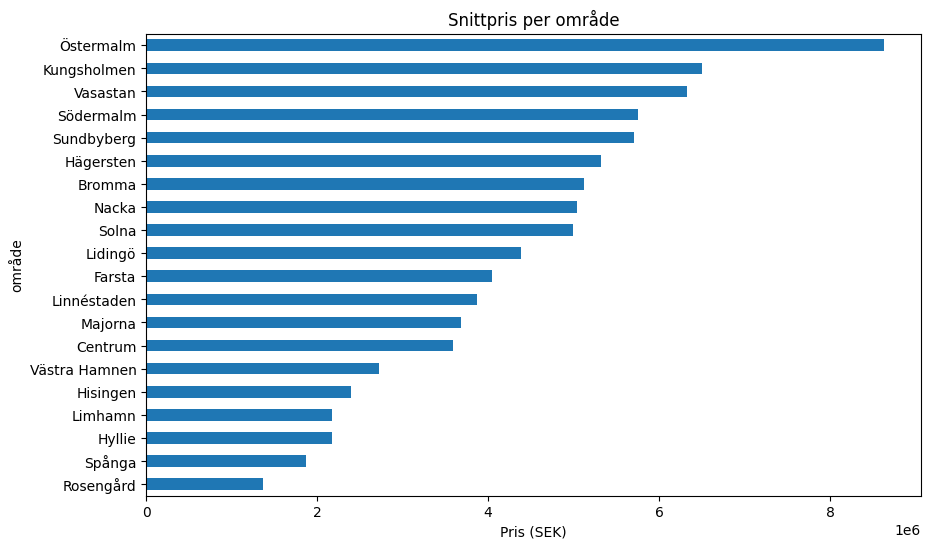

In [67]:
# Visa snittpris per område
df_merged2 = df_merged.merge(df_platser, on="plats_id")

df_merged2.groupby("område")["pris"].mean().sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Snittpris per område")
plt.xlabel("Pris (SEK)")
plt.show()

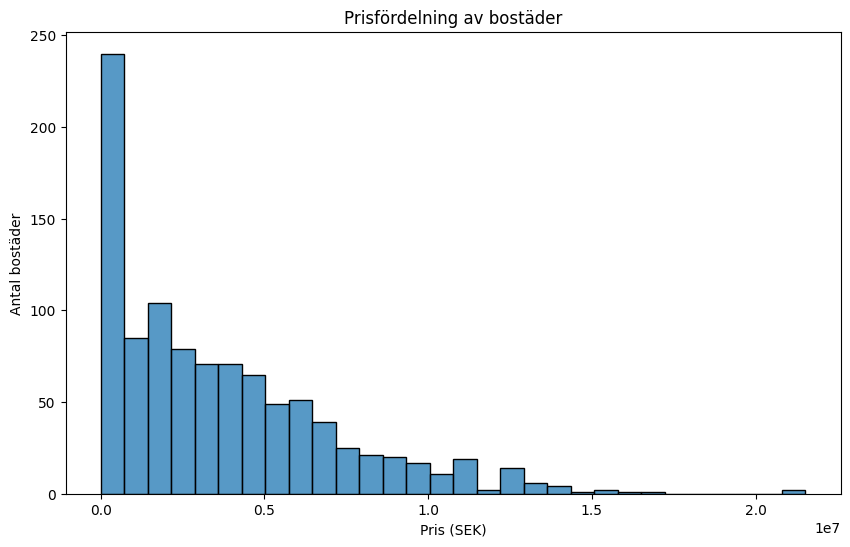

In [68]:
# Visa prisfördelning
plt.figure(figsize=(10,6))
sns.histplot(df_merged2["pris"], bins=30)
plt.title("Prisfördelning av bostäder")
plt.xlabel("Pris (SEK)")
plt.ylabel("Antal bostäder")
plt.show()

#### Använder SQL för att analysera data på ett strukturerat sätt, precis som man skulle göra mot en riktig databas 

In [69]:
import duckdb 

# Använd DuckDB för att köra SQL-frågor på DataFrame
con = duckdb.connect()
con.register("right_home", df_merged2)


In [70]:
con.execute("SELECT * FROM right_home LIMIT 5").df()

,id,typ,upplåtelseform,rum,boyta,boyta_enhet,tillgänglig,created_at,adress,lat,...,bostad_id,pris,avgift,kvadratmeterpris,pris_per_kvm,valuta,manadskostnad,område,stad,kommun_befolkning
0,1,lägenhet,köpa,5,100,m²,False,2025-09-30,Drottninggatan 19,55.55919,...,1,3367479,6619,33674,33675.0,SEK,22123,Hyllie,Malmö,365644
1,2,hus,köpa,1,20,m²,True,2025-06-05,Bergsgatan 93,59.33706,...,2,2336351,3194,116817,116818.0,SEK,13950,Östermalm,Stockholm,995574
2,3,hus,köpa,6,126,m²,True,2025-12-11,Lindvägen 89,55.58954,...,3,2814259,3519,22335,22335.0,SEK,16476,Rosengård,Malmö,365644
3,4,lägenhet,köpa,2,36,m²,True,2025-09-14,Storgatan 117,55.61235,...,4,1557389,1519,43260,43261.0,SEK,8689,Västra Hamnen,Malmö,365644
4,5,lägenhet,hyra,6,138,m²,True,2026-02-25,Sveavägen 119,55.58740,...,5,19590,0,0,142.0,SEK,19590,Rosengård,Malmö,365644


In [71]:
# Visa snittpris per område med SQL
con.execute("""
    SELECT område, 
           ROUND(AVG(pris), 0) as snittpris,
           COUNT(*) as antal
    FROM right_home
    GROUP BY område
    ORDER BY snittpris DESC
""").df()

,område,snittpris,antal
0,Östermalm,8631969.0,23
1,Kungsholmen,6501530.0,27
2,Vasastan,6324062.0,25
3,Södermalm,5755663.0,33
4,Sundbyberg,5706663.0,28
5,Hägersten,5318179.0,32
6,Bromma,5115424.0,28
7,Nacka,5043640.0,39
8,Solna,4996165.0,33
9,Lidingö,4383054.0,30


In [72]:
# hyra mot köp 
con.execute("""
    SELECT upplåtelseform,
           COUNT(*) as antal,
           ROUND(AVG(pris), 0) as snittpris,
           MIN(pris) as lägsta,
           MAX(pris) as högsta
    FROM right_home
    GROUP BY upplåtelseform
""").df()

,upplåtelseform,antal,snittpris,lägsta,högsta
0,hyra,228,12386.0,2379,28108
1,köpa,772,4697527.0,420499,21524262


In [73]:
# Tillgängliga bostäder per stad 
con.execute("""
    SELECT stad,
           COUNT(*) as antal,
           SUM(CASE WHEN tillgänglig = true THEN 1 ELSE 0 END) as tillgängliga
    FROM right_home
    GROUP BY stad
""").df()

,stad,antal,tillgängliga
0,Malmö,335,259.0
1,Göteborg,314,235.0
2,Stockholm,351,255.0


In [74]:
import os
print(os.getcwd())

/Users/zinebmouhib/Documents/UX25_DE25_Projekt_Group3/notebooks


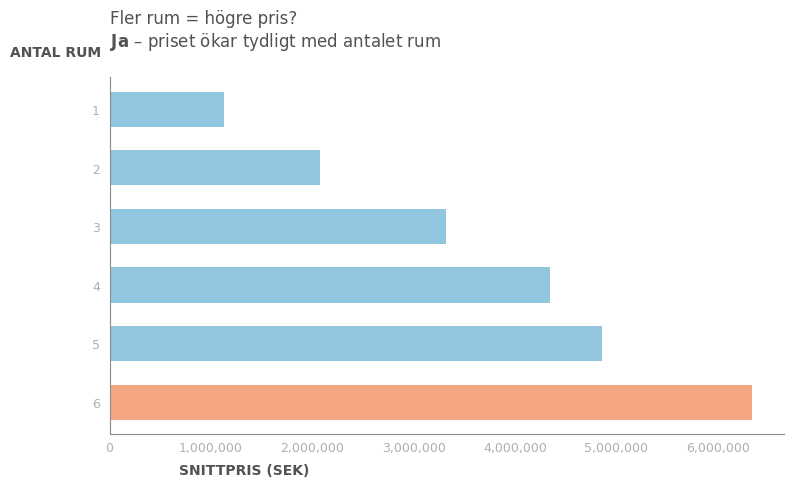

In [75]:
GRAY_1 = "#8c8c8c"
GRAY_2 = "#b0b0b0"
GRAY_3 = "#525252"

df_plot3 = df_merged2.groupby("rum")["pris"].mean().sort_values()
max_val = df_plot3.idxmax()
colors3 = ["#f4a582" if k == max_val else "#92c5de" for k in df_plot3.index]

fig, ax = plt.subplots(figsize=(8, 5))
df_plot3.plot(kind="barh", ax=ax, width=0.6, color=colors3)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRAY_1)

ax.tick_params(axis="both", colors=GRAY_2, labelsize=9, length=0, pad=5)
ax.tick_params(axis="y", pad=7)

ax.set_xlabel("SNITTPRIS (SEK)", color=GRAY_3, fontweight="bold")
ax.set_ylabel("ANTAL RUM", color=GRAY_3, fontweight="bold", rotation=0)
ax.yaxis.set_label_coords(-0.08, 1.05)
ax.xaxis.set_label_coords(0.2, -0.08)

ax.set_title(
    "Fler rum = högre pris?\n"
    + r"$\bf{Ja}$"
    + " – priset ökar tydligt med antalet rum",
    loc="left", color=GRAY_3, pad=22
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.invert_yaxis()
fig.tight_layout()
plt.show()

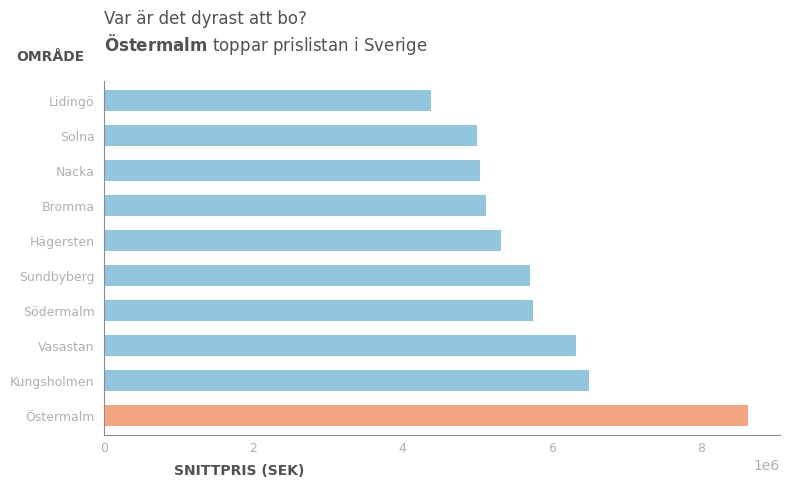

In [76]:
GRAY_1 = "#8c8c8c"
GRAY_2 = "#b0b0b0"
GRAY_3 = "#525252"


df_plot2 = df_merged2.groupby("område")["pris"].mean().sort_values(ascending=False).head(10)

top_område = df_plot2.idxmax()  # hämtar det faktiska toppområdet dynamiskt
colors2 = ["#f4a582" if o == top_område else "#92c5de" for o in df_plot2.sort_values().index]

fig, ax = plt.subplots(figsize=(8, 5))
df_plot2.sort_values().plot(kind="barh", ax=ax, width=0.6, color=colors2)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRAY_1)

ax.tick_params(axis="both", colors=GRAY_2, labelsize=9, length=0, pad=5)
ax.tick_params(axis="y", pad=7)

ax.set_xlabel("SNITTPRIS (SEK)", color=GRAY_3, fontweight="bold")
ax.set_ylabel("OMRÅDE", color=GRAY_3, fontweight="bold", rotation=0)
ax.yaxis.set_label_coords(-0.08, 1.05)
ax.xaxis.set_label_coords(0.2, -0.08)

ax.set_title(
    "Var är det dyrast att bo?\n"
    + r"$\bf{" + top_område + "}$"
    + " toppar prislistan i Sverige",
    loc="left", color=GRAY_3, pad=22
)

ax.invert_yaxis()
fig.tight_layout()
plt.show()
